# LOSO CV: 3-Day Batch SGD — MT, ID, ND, SD, WY

Multi-state batchwise LOSO with **3 days per batch** (~201 obs/epoch).
Compared to 1-day batching (~67 obs/epoch), this provides more stable gradients
at the cost of seeing fewer unique days per training run.

**Kernel:** `Base_RBF_ARD + AOT×Season + SmogI/P×Season + Residual_Season`

In [1]:
# Training already completed — results loaded from saved files
# To re-run: python loso_cv_daily_parallel.py --n_days 3 --n_epochs 1000 --patience 30 \
#   --inference_days '25,50,100,150,200,250,300,350,400' --n_gpus 4
print("Loading pre-computed 3-day results...")

Loading pre-computed 3-day results...


## Results

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PREFIX = '3day_parallel'

with open(f'{PREFIX}_results.json') as f:
    results = json.load(f)

metrics_df = pd.read_csv(f'{PREFIX}_site_metrics.csv')
params_df = pd.read_csv(f'{PREFIX}_kernel_params.csv')
timing_df = pd.read_csv(f'{PREFIX}_fold_timings.csv')
sweep_df = pd.read_csv(f'{PREFIX}_inference_sweep.csv')
data = np.load(f'{PREFIX}_predictions.npz')

print('=' * 60)
print('LOSO CV Results (3-Day Batch SGD, MT/ID/ND/SD/WY)')
print('=' * 60)
o = results['overall']
c = results['config']
print(f"Training: {c['training']}, n_days={c['n_days']}, patience={c['patience']}")
print(f"States: {c['states']}")
print(f"Log scale:  RMSE={o['rmse_log']:.4f}, MAE={o['mae_log']:.4f}, R²={o['r2_log']:.4f}")
print(f"Orig scale: RMSE={o['rmse_orig']:.2f}, MAE={o['mae_orig']:.2f}, R²={o['r2_orig']:.4f}")
print(f"Total time: {o['total_time']:.1f}s")
print(f"Sites: {len(metrics_df)}, Predictions: {o['n_predictions']}")
print()
print("Batch structure:")
print(f"  Avg batch size: {timing_df['avg_batch_size'].mean():.0f} obs/epoch")
print(f"  Stopped epochs: mean={timing_df['stopped_epoch'].mean():.0f}, "
      f"min={timing_df['stopped_epoch'].min()}, max={timing_df['stopped_epoch'].max()}")
print()
print("Per-state site counts and R²:")
for st in c['states']:
    st_metrics = metrics_df[metrics_df['state'] == st]
    if len(st_metrics) > 0:
        print(f"  {st}: {len(st_metrics)} sites, median R²={st_metrics['r2_log'].median():.3f}")
print()
print("Overall site-level R² summary:")
print(metrics_df['r2_log'].describe())

LOSO CV Results (3-Day Batch SGD, MT/ID/ND/SD/WY)
Training: daily_batch_sgd, n_days=3, patience=30
States: ['MT', 'ID', 'ND', 'SD', 'WY']
Log scale:  RMSE=0.5483, MAE=0.4233, R²=0.3953
Orig scale: RMSE=4.59, MAE=2.70, R²=0.4379
Total time: 599.3s
Sites: 112, Predictions: 48852

Batch structure:
  Avg batch size: 199 obs/epoch
  Stopped epochs: mean=106, min=63, max=174

Per-state site counts and R²:
  MT: 32 sites, median R²=0.197
  ID: 38 sites, median R²=0.132
  ND: 6 sites, median R²=-0.043
  SD: 2 sites, median R²=0.360
  WY: 34 sites, median R²=0.343

Overall site-level R² summary:
count    112.000000
mean      -0.753684
std        5.153563
min      -49.775573
25%       -0.191636
50%        0.182242
75%        0.400323
max        0.754594
Name: r2_log, dtype: float64


## Inference Size Sweep

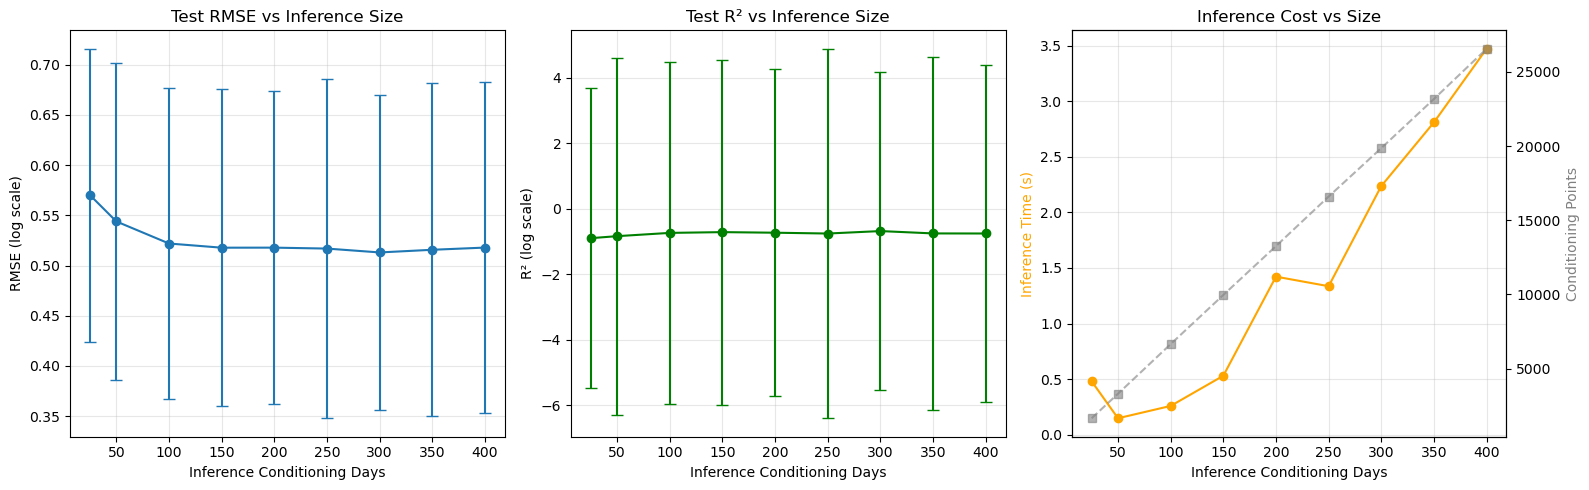

 inference_days  mean_n_points  mean_rmse  mean_mae   mean_r2  mean_infer_time
             25    1654.044643   0.570130  0.455446 -0.896187         0.480362
             50    3308.696429   0.543963  0.435530 -0.834899         0.148084
            100    6651.580357   0.521991  0.418073 -0.735050         0.258841
            150    9965.080357   0.517827  0.416110 -0.711741         0.530459
            200   13258.973214   0.517876  0.415940 -0.729689         1.422254
            250   16601.062500   0.516943  0.415824 -0.754552         1.336128
            300   19867.482143   0.513094  0.411571 -0.679466         2.237343
            350   23180.473214   0.515742  0.414403 -0.751357         2.810526
            400   26562.812500   0.517932  0.417465 -0.753684         3.472045


In [3]:
sweep_overall = sweep_df.groupby('inference_days').agg(
    mean_rmse=('rmse_log', 'mean'),
    std_rmse=('rmse_log', 'std'),
    mean_mae=('mae_log', 'mean'),
    std_mae=('mae_log', 'std'),
    mean_r2=('r2_log', 'mean'),
    std_r2=('r2_log', 'std'),
    mean_infer_time=('infer_time', 'mean'),
    mean_n_points=('n_infer_points', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].errorbar(sweep_overall['inference_days'], sweep_overall['mean_rmse'],
                 yerr=sweep_overall['std_rmse'], marker='o', capsize=4)
axes[0].set_xlabel('Inference Conditioning Days')
axes[0].set_ylabel('RMSE (log scale)')
axes[0].set_title('Test RMSE vs Inference Size')
axes[0].grid(True, alpha=0.3)

axes[1].errorbar(sweep_overall['inference_days'], sweep_overall['mean_r2'],
                 yerr=sweep_overall['std_r2'], marker='o', capsize=4, color='green')
axes[1].set_xlabel('Inference Conditioning Days')
axes[1].set_ylabel('R² (log scale)')
axes[1].set_title('Test R² vs Inference Size')
axes[1].grid(True, alpha=0.3)

axes[2].plot(sweep_overall['inference_days'], sweep_overall['mean_infer_time'],
             marker='o', color='orange')
ax2 = axes[2].twinx()
ax2.plot(sweep_overall['inference_days'], sweep_overall['mean_n_points'],
         marker='s', color='gray', linestyle='--', alpha=0.6)
ax2.set_ylabel('Conditioning Points', color='gray')
axes[2].set_xlabel('Inference Conditioning Days')
axes[2].set_ylabel('Inference Time (s)', color='orange')
axes[2].set_title('Inference Cost vs Size')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(sweep_overall[['inference_days', 'mean_n_points', 'mean_rmse', 'mean_mae',
                      'mean_r2', 'mean_infer_time']].to_string(index=False))

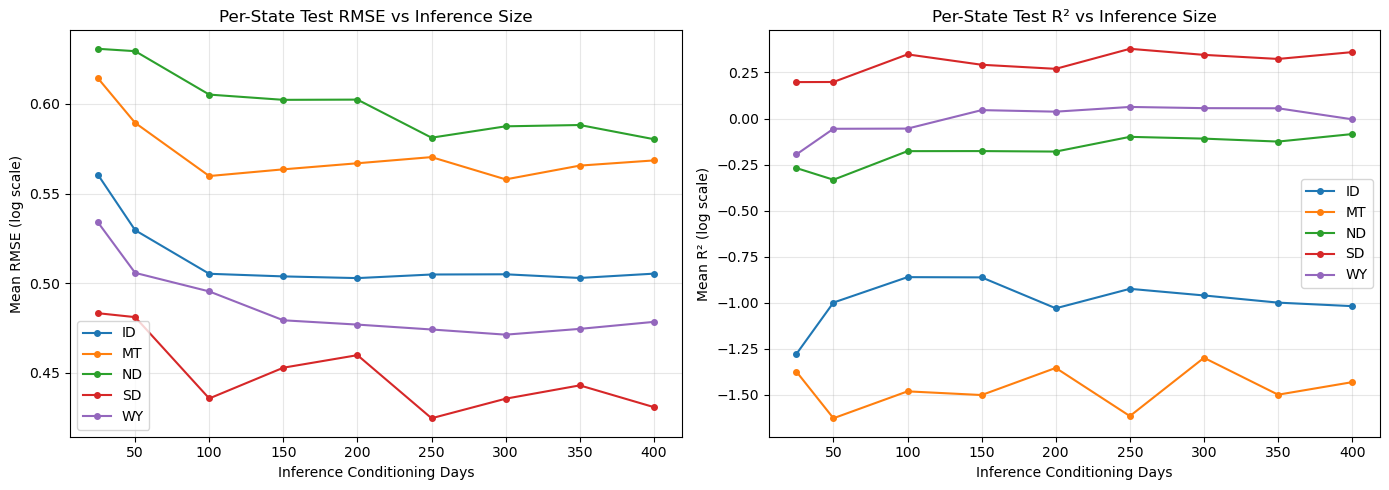

In [4]:
# Per-state inference sweep
states = sorted(sweep_df['state'].unique())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for st in states:
    st_sweep = sweep_df[sweep_df['state'] == st].groupby('inference_days').agg(
        mean_rmse=('rmse_log', 'mean'),
        mean_r2=('r2_log', 'mean'),
    ).reset_index()
    axes[0].plot(st_sweep['inference_days'], st_sweep['mean_rmse'], marker='o', label=st, markersize=4)
    axes[1].plot(st_sweep['inference_days'], st_sweep['mean_r2'], marker='o', label=st, markersize=4)

axes[0].set_xlabel('Inference Conditioning Days')
axes[0].set_ylabel('Mean RMSE (log scale)')
axes[0].set_title('Per-State Test RMSE vs Inference Size')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Inference Conditioning Days')
axes[1].set_ylabel('Mean R² (log scale)')
axes[1].set_title('Per-State Test R² vs Inference Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Training Loss

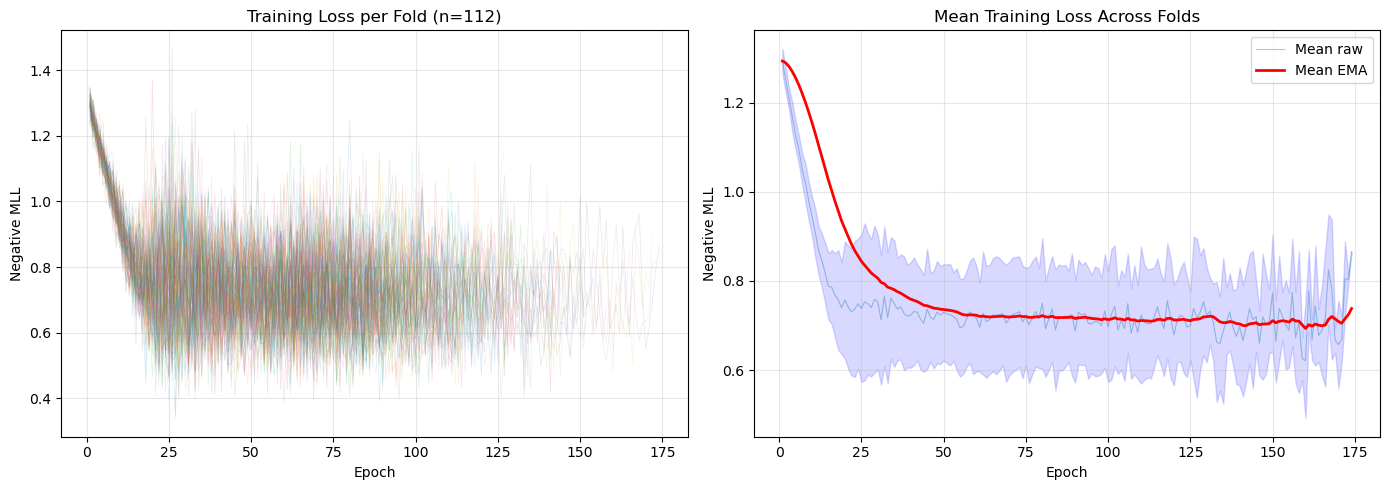

Min mean raw loss at epoch 160: 0.6215
Final EMA: 0.7382


In [5]:
fold_losses = results['fold_losses']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for site, losses in fold_losses.items():
    axes[0].plot(range(1, len(losses)+1), losses, alpha=0.15, linewidth=0.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Negative MLL')
axes[0].set_title(f'Training Loss per Fold (n={len(fold_losses)})')
axes[0].grid(True, alpha=0.3)

max_len = max(len(v) for v in fold_losses.values())
loss_matrix = np.full((len(fold_losses), max_len), np.nan)
for i, losses in enumerate(fold_losses.values()):
    loss_matrix[i, :len(losses)] = losses
mean_loss = np.nanmean(loss_matrix, axis=0)
std_loss = np.nanstd(loss_matrix, axis=0)
epochs = np.arange(1, len(mean_loss)+1)

ema = [mean_loss[0]]
for l in mean_loss[1:]:
    ema.append(0.9 * ema[-1] + 0.1 * (l if not np.isnan(l) else ema[-1]))

axes[1].plot(epochs, mean_loss, alpha=0.4, linewidth=0.8, label='Mean raw')
axes[1].plot(epochs[:len(ema)], ema, 'r-', linewidth=2, label='Mean EMA')
axes[1].fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss,
                     alpha=0.15, color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Negative MLL')
axes[1].set_title('Mean Training Loss Across Folds')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

min_epoch = np.nanargmin(mean_loss) + 1
print(f'Min mean raw loss at epoch {min_epoch}: {np.nanmin(mean_loss):.4f}')
print(f'Final EMA: {ema[-1]:.4f}')

## Predictions (largest inference size)

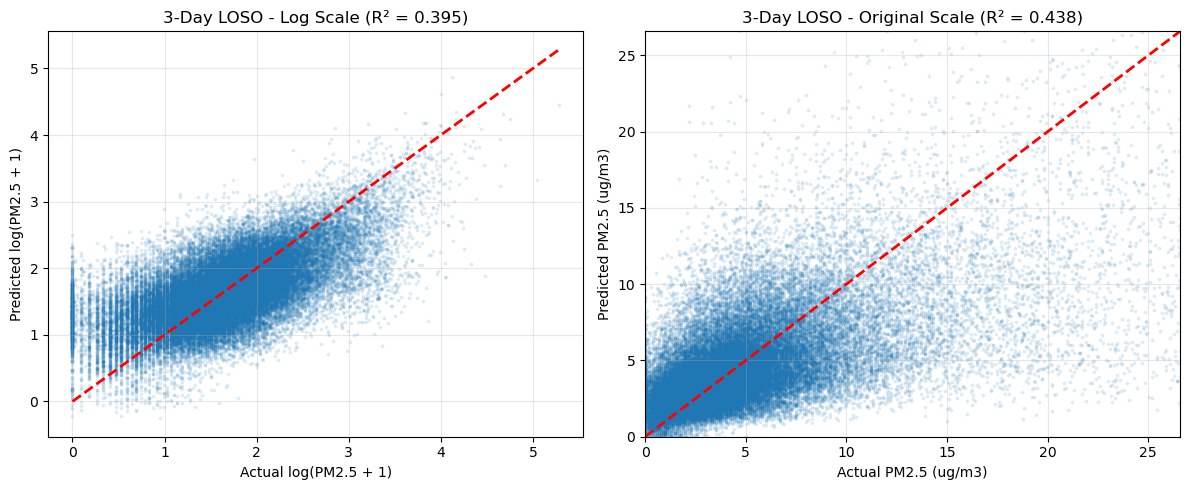

In [6]:
all_pred = data['predictions']
all_actual = data['actuals']
pred_pm25 = data['pred_pm25']
actual_pm25 = data['actual_pm25']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_actual, all_pred, alpha=0.1, s=3)
axes[0].plot([all_actual.min(), all_actual.max()],
             [all_actual.min(), all_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(PM2.5 + 1)')
axes[0].set_ylabel('Predicted log(PM2.5 + 1)')
axes[0].set_title(f'3-Day LOSO - Log Scale (R² = {o["r2_log"]:.3f})')
axes[0].grid(True, alpha=0.3)

max_val = np.percentile(np.concatenate([actual_pm25, pred_pm25]), 99)
axes[1].scatter(actual_pm25, pred_pm25, alpha=0.1, s=3)
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Actual PM2.5 (ug/m3)')
axes[1].set_ylabel('Predicted PM2.5 (ug/m3)')
axes[1].set_title(f'3-Day LOSO - Original Scale (R² = {o["r2_orig"]:.3f})')
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Site-Level Analysis

/tmp/ipykernel_1906752/3448232822.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(state_r2_data, labels=states, patch_artist=True)


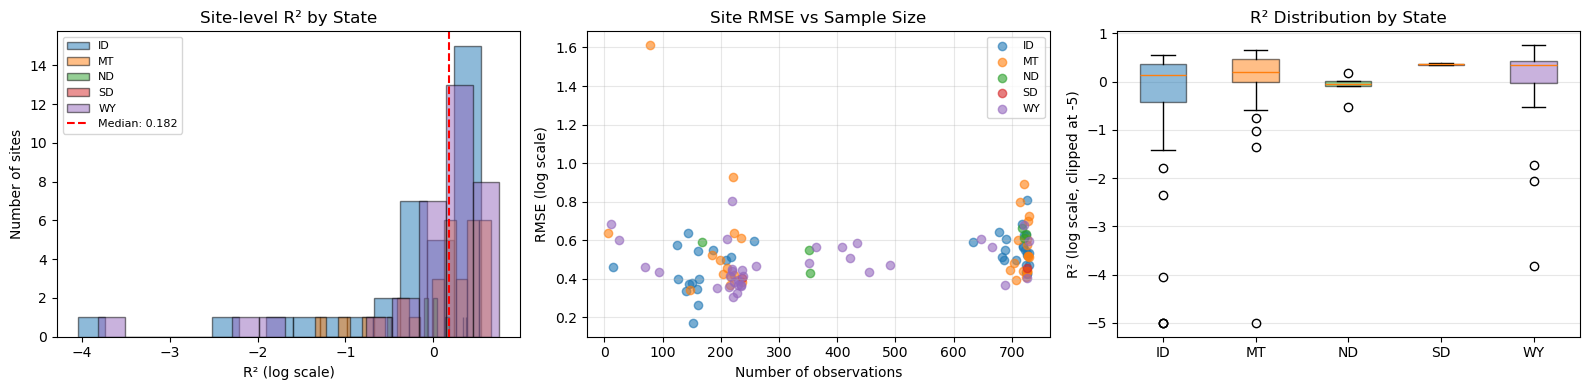

Top 5 best sites:
        site state  n_obs  rmse_log   r2_log
110401_44565    WY    221  0.304292 0.754594
111712_46826    MT    147  0.344346 0.656139
115672_47955    MT    218  0.409399 0.633238
109640_42846    WY    229  0.368705 0.627494
114001_45860    MT    236  0.384749 0.625539

Top 5 worst sites:
        site state  n_obs  rmse_log     r2_log
115195_48971    MT     78  1.611618 -49.775573
113787_42608    ID    161  0.543542 -19.959577
116979_44262    ID    141  0.334406  -6.120347
116359_48894    ID    124  0.577224  -5.554938
116359_48998    ID    126  0.401023  -4.046751


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

states = sorted(metrics_df['state'].unique())
colors = plt.cm.tab10(range(len(states)))

for i, st in enumerate(states):
    st_r2 = metrics_df[metrics_df['state'] == st]['r2_log'].dropna()
    st_r2_clipped = st_r2[st_r2 > -5]
    axes[0].hist(st_r2_clipped, bins=15, alpha=0.5, label=st, color=colors[i], edgecolor='black')
axes[0].axvline(x=metrics_df['r2_log'].median(), color='r', linestyle='--',
                label=f'Median: {metrics_df["r2_log"].median():.3f}')
axes[0].set_xlabel('R² (log scale)')
axes[0].set_ylabel('Number of sites')
axes[0].set_title('Site-level R² by State')
axes[0].legend(fontsize=8)

for i, st in enumerate(states):
    mask = metrics_df['state'] == st
    axes[1].scatter(metrics_df.loc[mask, 'n_obs'], metrics_df.loc[mask, 'rmse_log'],
                    alpha=0.6, label=st, color=colors[i])
axes[1].set_xlabel('Number of observations')
axes[1].set_ylabel('RMSE (log scale)')
axes[1].set_title('Site RMSE vs Sample Size')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

state_r2_data = [metrics_df[metrics_df['state'] == st]['r2_log'].clip(lower=-5).values
                 for st in states]
bp = axes[2].boxplot(state_r2_data, labels=states, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[2].set_ylabel('R² (log scale, clipped at -5)')
axes[2].set_title('R² Distribution by State')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Top 5 best sites:')
print(metrics_df.nlargest(5, 'r2_log')[['site', 'state', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))
print()
print('Top 5 worst sites:')
print(metrics_df.nsmallest(5, 'r2_log')[['site', 'state', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))

## Kernel Parameters

In [8]:
print('Learned kernel output scales:')
print(f"{'Component':<25} {'Mean':>8} {'Std':>8}")
print('-' * 45)
for col, label in [('base_scale', 'Base RBF_ARD'),
                    ('summer_scale', 'AOT x Season'),
                    ('winter_scale', 'SmogI/P x Season'),
                    ('seasonal_scale', 'Residual Seasonal')]:
    print(f'{label:<25} {params_df[col].mean():>8.4f} {params_df[col].std():>8.4f}')

print()
print('Learned periods (days):')
for col, label in [('aot_period_days', 'AOT periodic'),
                    ('smog_period_days', 'Smog periodic'),
                    ('residual_period_days', 'Residual periodic')]:
    print(f'{label:<25} {params_df[col].mean():>8.1f} {params_df[col].std():>8.1f}')

print()
print(f'Noise: mean={params_df["noise"].mean():.4f}, std={params_df["noise"].std():.4f}')

Learned kernel output scales:
Component                     Mean      Std
---------------------------------------------
Base RBF_ARD                0.1087   0.0093
AOT x Season                0.0505   0.0171
SmogI/P x Season            0.3266   0.0442
Residual Seasonal           0.0899   0.0885

Learned periods (days):
AOT periodic                 474.6     68.5
Smog periodic                294.5     53.1
Residual periodic            444.5     73.0

Noise: mean=0.1380, std=0.0124


## Convergence Analysis

/tmp/ipykernel_1906752/3669363377.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(epoch_data, labels=states, patch_artist=True)


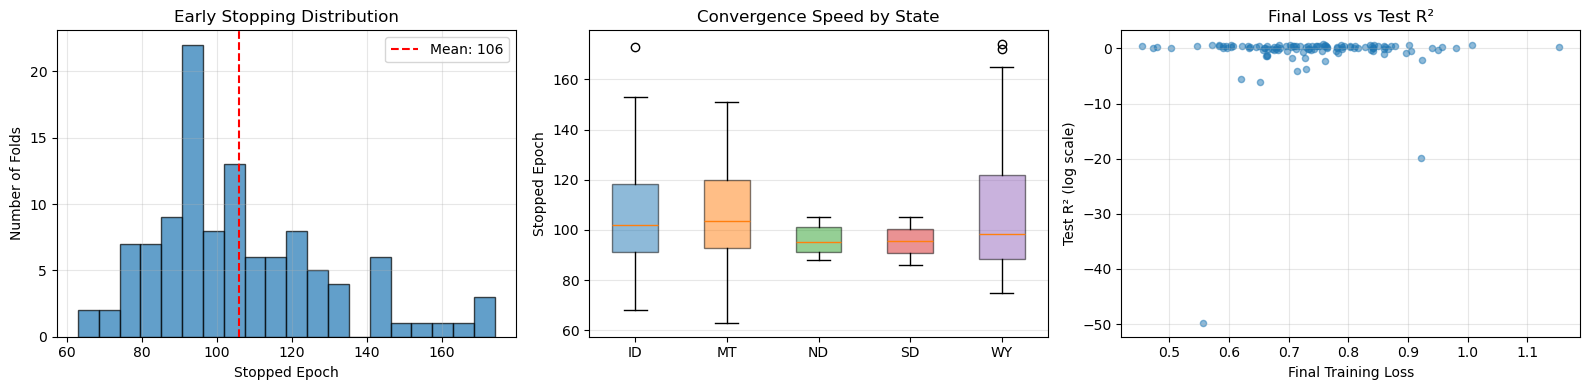

Convergence summary:
  Mean stopped epoch: 106
  Median stopped epoch: 100
  Folds reaching max epochs: 0


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(timing_df['stopped_epoch'], bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(timing_df['stopped_epoch'].mean(), color='r', linestyle='--',
                label=f'Mean: {timing_df["stopped_epoch"].mean():.0f}')
axes[0].set_xlabel('Stopped Epoch')
axes[0].set_ylabel('Number of Folds')
axes[0].set_title('Early Stopping Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

states = sorted(timing_df['state'].unique())
colors = plt.cm.tab10(range(len(states)))
epoch_data = [timing_df[timing_df['state'] == st]['stopped_epoch'].values for st in states]
bp = axes[1].boxplot(epoch_data, labels=states, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[1].set_ylabel('Stopped Epoch')
axes[1].set_title('Convergence Speed by State')
axes[1].grid(True, alpha=0.3, axis='y')

final_losses = []
for site, losses in fold_losses.items():
    final_losses.append(losses[-1])
site_order = list(fold_losses.keys())
r2_vals = []
for s in site_order:
    r2_row = metrics_df[metrics_df['site'] == s]
    r2_vals.append(r2_row['r2_log'].values[0] if len(r2_row) > 0 else np.nan)

axes[2].scatter(final_losses, r2_vals, alpha=0.5, s=20)
axes[2].set_xlabel('Final Training Loss')
axes[2].set_ylabel('Test R² (log scale)')
axes[2].set_title('Final Loss vs Test R²')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Convergence summary:")
print(f"  Mean stopped epoch: {timing_df['stopped_epoch'].mean():.0f}")
print(f"  Median stopped epoch: {timing_df['stopped_epoch'].median():.0f}")
print(f"  Folds reaching max epochs: {(timing_df['stopped_epoch'] == c['n_epochs']).sum()}")

## Timings

/tmp/ipykernel_1906752/1032985453.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(fold_time_data, labels=states, patch_artist=True)


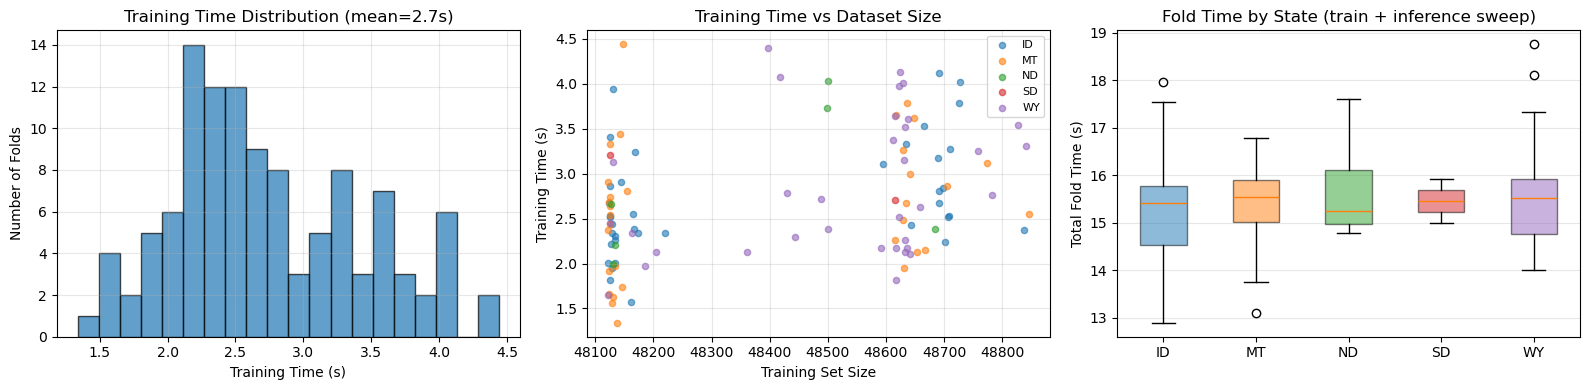

Timing summary:
  Total wall time: 599.3s (10.0 min)
  Mean training time per fold: 2.7s
  Mean total fold time: 15.4s
  Avg batch size: 199 obs/epoch

Per-state timing:
  ID: 38 folds, mean train=2.7s, mean fold=15.3s
  MT: 32 folds, mean train=2.6s, mean fold=15.3s
  ND: 6 folds, mean train=2.8s, mean fold=15.7s
  SD: 2 folds, mean train=3.0s, mean fold=15.5s
  WY: 34 folds, mean train=2.8s, mean fold=15.6s


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(timing_df['train_time'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Training Time (s)')
axes[0].set_ylabel('Number of Folds')
axes[0].set_title(f'Training Time Distribution (mean={timing_df["train_time"].mean():.1f}s)')
axes[0].grid(True, alpha=0.3)

for i, st in enumerate(states):
    mask = timing_df['state'] == st
    axes[1].scatter(timing_df.loc[mask, 'n_train'], timing_df.loc[mask, 'train_time'],
                    alpha=0.6, label=st, color=colors[i], s=20)
axes[1].set_xlabel('Training Set Size')
axes[1].set_ylabel('Training Time (s)')
axes[1].set_title('Training Time vs Dataset Size')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fold_time_data = [timing_df[timing_df['state'] == st]['fold_time'].values for st in states]
bp = axes[2].boxplot(fold_time_data, labels=states, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[2].set_ylabel('Total Fold Time (s)')
axes[2].set_title('Fold Time by State (train + inference sweep)')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Timing summary:")
print(f"  Total wall time: {o['total_time']:.1f}s ({o['total_time']/60:.1f} min)")
print(f"  Mean training time per fold: {timing_df['train_time'].mean():.1f}s")
print(f"  Mean total fold time: {timing_df['fold_time'].mean():.1f}s")
print(f"  Avg batch size: {timing_df['avg_batch_size'].mean():.0f} obs/epoch")
print()
print("Per-state timing:")
for st in states:
    st_t = timing_df[timing_df['state'] == st]
    print(f"  {st}: {len(st_t)} folds, mean train={st_t['train_time'].mean():.1f}s, "
          f"mean fold={st_t['fold_time'].mean():.1f}s")

## Comparison: 1-Day vs 3-Day Batching

Metric                                   1-Day           3-Day
Batch size (obs/epoch)                      66             199
Mean stopped epoch                          94             106
RMSE (log)                              0.5471          0.5483
MAE (log)                               0.4220          0.4233
R² (log)                                0.3979          0.3953
R² (orig)                               0.4497          0.4379
Median site R² (log)                     0.220           0.182
Wall time (s)                            607.5           599.3

Per-state R² comparison (log scale):
  MT: 1-day median=0.294, 3-day median=0.197 (32 sites)
  ID: 1-day median=0.099, 3-day median=0.132 (38 sites)
  ND: 1-day median=-0.038, 3-day median=-0.043 (6 sites)
  SD: 1-day median=0.379, 3-day median=0.360 (2 sites)
  WY: 1-day median=0.309, 3-day median=0.343 (34 sites)


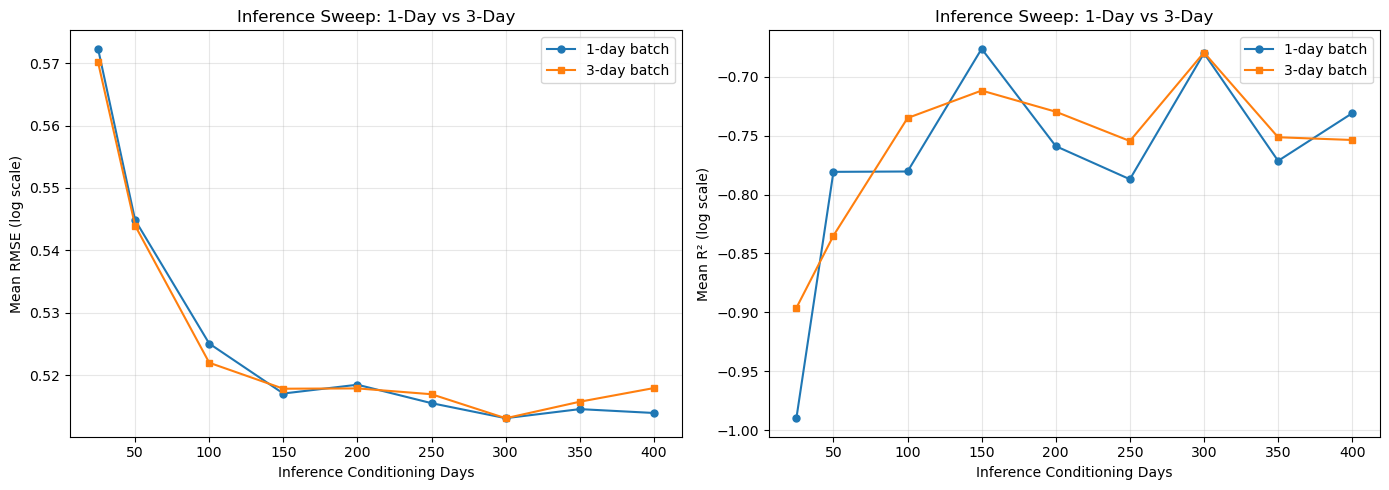

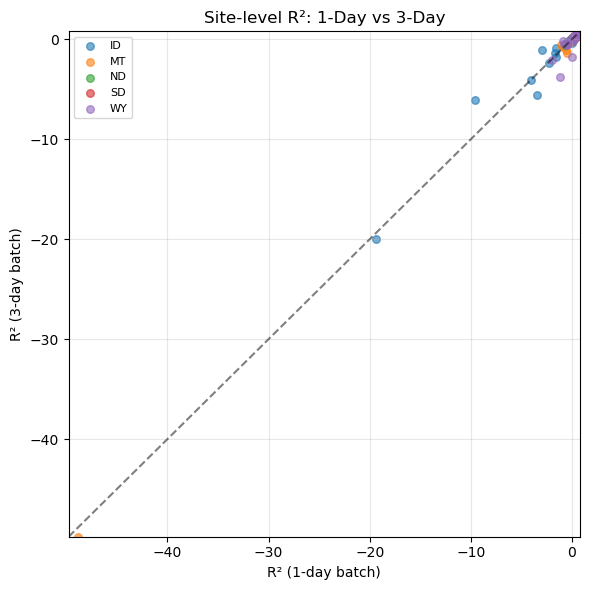


3-day better at 54/112 sites (48%)


In [11]:
import os

# Load 1-day results if available
if os.path.exists('daily_parallel_results.json'):
    with open('daily_parallel_results.json') as f:
        r1 = json.load(f)
    m1 = pd.read_csv('daily_parallel_site_metrics.csv')
    t1 = pd.read_csv('daily_parallel_fold_timings.csv')
    s1 = pd.read_csv('daily_parallel_inference_sweep.csv')

    with open(f'{PREFIX}_results.json') as f:
        r3 = json.load(f)
    m3 = metrics_df
    t3 = timing_df
    s3 = sweep_df

    print("=" * 65)
    print(f"{'Metric':<30} {'1-Day':>15} {'3-Day':>15}")
    print("=" * 65)
    print(f"{'Batch size (obs/epoch)':<30} {t1['avg_batch_size'].mean():>15.0f} {t3['avg_batch_size'].mean():>15.0f}")
    print(f"{'Mean stopped epoch':<30} {t1['stopped_epoch'].mean():>15.0f} {t3['stopped_epoch'].mean():>15.0f}")
    print(f"{'RMSE (log)':<30} {r1['overall']['rmse_log']:>15.4f} {r3['overall']['rmse_log']:>15.4f}")
    print(f"{'MAE (log)':<30} {r1['overall']['mae_log']:>15.4f} {r3['overall']['mae_log']:>15.4f}")
    print(f"{'R² (log)':<30} {r1['overall']['r2_log']:>15.4f} {r3['overall']['r2_log']:>15.4f}")
    print(f"{'R² (orig)':<30} {r1['overall']['r2_orig']:>15.4f} {r3['overall']['r2_orig']:>15.4f}")
    print(f"{'Median site R² (log)':<30} {m1['r2_log'].median():>15.3f} {m3['r2_log'].median():>15.3f}")
    print(f"{'Wall time (s)':<30} {r1['overall']['total_time']:>15.1f} {r3['overall']['total_time']:>15.1f}")

    # Per-state comparison
    print()
    print("Per-state R² comparison (log scale):")
    for st in ['MT', 'ID', 'ND', 'SD', 'WY']:
        r1_st = m1[m1['state'] == st]['r2_log'].median() if st in m1['state'].values else float('nan')
        r3_st = m3[m3['state'] == st]['r2_log'].median() if st in m3['state'].values else float('nan')
        n_sites = len(m3[m3['state'] == st])
        print(f"  {st}: 1-day median={r1_st:.3f}, 3-day median={r3_st:.3f} ({n_sites} sites)")

    # Inference sweep comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    s1_agg = s1.groupby('inference_days')['rmse_log'].mean().reset_index()
    s3_agg = s3.groupby('inference_days')['rmse_log'].mean().reset_index()
    axes[0].plot(s1_agg['inference_days'], s1_agg['rmse_log'], 'o-', label='1-day batch', markersize=5)
    axes[0].plot(s3_agg['inference_days'], s3_agg['rmse_log'], 's-', label='3-day batch', markersize=5)
    axes[0].set_xlabel('Inference Conditioning Days')
    axes[0].set_ylabel('Mean RMSE (log scale)')
    axes[0].set_title('Inference Sweep: 1-Day vs 3-Day')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    s1_r2 = s1.groupby('inference_days')['r2_log'].mean().reset_index()
    s3_r2 = s3.groupby('inference_days')['r2_log'].mean().reset_index()
    axes[1].plot(s1_r2['inference_days'], s1_r2['r2_log'], 'o-', label='1-day batch', markersize=5)
    axes[1].plot(s3_r2['inference_days'], s3_r2['r2_log'], 's-', label='3-day batch', markersize=5)
    axes[1].set_xlabel('Inference Conditioning Days')
    axes[1].set_ylabel('Mean R² (log scale)')
    axes[1].set_title('Inference Sweep: 1-Day vs 3-Day')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Site-level R² comparison
    merged = m1[['site', 'state', 'r2_log']].rename(columns={'r2_log': 'r2_1day'}).merge(
        m3[['site', 'r2_log']].rename(columns={'r2_log': 'r2_3day'}), on='site')

    fig, ax = plt.subplots(figsize=(6, 6))
    for i, st in enumerate(sorted(merged['state'].unique())):
        mask = merged['state'] == st
        ax.scatter(merged.loc[mask, 'r2_1day'], merged.loc[mask, 'r2_3day'],
                   alpha=0.6, label=st, color=plt.cm.tab10(i), s=30)
    lims = [min(merged[['r2_1day', 'r2_3day']].min().min(), -2),
            max(merged[['r2_1day', 'r2_3day']].max().max(), 0.8)]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlabel('R² (1-day batch)')
    ax.set_ylabel('R² (3-day batch)')
    ax.set_title('Site-level R²: 1-Day vs 3-Day')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    plt.tight_layout()
    plt.show()

    better = (merged['r2_3day'] > merged['r2_1day']).sum()
    print(f"\n3-day better at {better}/{len(merged)} sites ({100*better/len(merged):.0f}%)")
else:
    print("1-day results not found — run loso_cv_daily.ipynb first for comparison.")